In [11]:
import echopype as ep
import xarray as xr
import glob
import os
import warnings
import numpy as np

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# --- USER CONFIGURATION ---
input_folder = 'data_processed/2nd Deployment_ 55139_nc'   # Folder with your daily/hourly NC files
file_pattern = input("Enter the file pattern (e.g., '2304*.nc' for all April): ")

output_folder = 'data_products_monthly'
output_filename = '1711_5m.nc' # Name of the final file

# Mooring Definitions
mooring_depth = 159      # Sensor is at what m
bad_line_min = 97        # Interference top
bad_line_max = 102       # Interference bottom
surface_cutoff = 0       # Keep data only DEEPER than 0m (Remove surface)
bottom_cutoff = 157      # Keep data only SHALLOWER than 158m (Remove Bottom)

# Binning Resolution
res_time = "1H"          # 1 Hour resolution
res_depth = "5m"         # 5 Meter resolution

# ---------------------------

# 1. Setup Output Directory
os.makedirs(output_folder, exist_ok=True) # if no output folder, create it

# 2. Find Files
search_path = os.path.join(input_folder, file_pattern)
file_list = sorted(glob.glob(search_path))

print(f"Found {len(file_list)} files. Starting processing...")
print(f"Target: Single file with {res_time} x {res_depth}m resolution.")
print(f"Applying Masks: Surface (<{surface_cutoff}m), Bottom (>{bottom_cutoff}) and Lines ({bad_line_min}-{bad_line_max}m)")

mvbs_datasets = []

# 3. Main Processing Loop
for i, file in enumerate(file_list):
    try:
        print(f"[{i+1}/{len(file_list)}] Processing {os.path.basename(file)}...", end='\r')
        
        # A. Open & Calibrate
        ed = ep.open_converted(file)
        env_params = {
            'temperature': 4, 
            'salinity': 35, 
            'pressure': mooring_depth * 1.01
        }
        ds_Sv = ep.calibrate.compute_Sv(ed, env_params=env_params)

        # B. Robust Echo Range Extraction
        # (Ensures we can calculate depth even if metadata varies)
        if 'echo_range' in ds_Sv.coords:
            range_var = ds_Sv.coords['echo_range']
        elif 'echo_range' in ds_Sv.data_vars:
            range_var = ds_Sv.data_vars['echo_range']
            ds_Sv = ds_Sv.assign_coords(echo_range=range_var)
        else:
            print(f"Skipping {os.path.basename(file)} (Missing echo_range)")
            continue

        # C. Calculate True Depth
        # Depth = Sensor Depth (168) - Range
        true_depth = mooring_depth - ds_Sv['echo_range']
        ds_Sv = ds_Sv.assign_coords(depth=true_depth)

        # --- D. APPLY MASKS (The "Filters") ---
        
        # Mask 1: Surface Removal (>0m means keep Depth > 0)
        # We replace any data shallower than 0m with NaN
        ds_Sv['Sv'] = ds_Sv['Sv'].where(ds_Sv['depth'] > surface_cutoff)

        # Mask 2: Bottom line Removal (<157m means keep Depth < 157m)
        # We replace any data deeper than 157m with NaN
        ds_Sv['Sv'] = ds_Sv['Sv'].where(ds_Sv['depth'] < bottom_cutoff)

        # Mask 2: Interference Lines (97-102m)
        # We keep data that is NOT in the bad zone
        mask_good_lines = (ds_Sv['depth'] < bad_line_min) | (ds_Sv['depth'] > bad_line_max)
        ds_Sv['Sv'] = ds_Sv['Sv'].where(mask_good_lines)

        # --- E. BINNING (Compute MVBS) ---
        # This condenses the data:
        # Time: Averages all pings in 1 Hour
        # Depth: Averages all samples in 5 Meter (Range)
        # Note: Binning by Range (1m) is equivalent to binning by Depth (1m)
        ds_mvbs = ep.commongrid.compute_MVBS(
            ds_Sv,
            range_var='depth',  # Use the calculated depth for binning
            range_bin=res_depth, 
            ping_time_bin=res_time
        )

        mvbs_datasets.append(ds_mvbs)

    except Exception as e:
        print(f"\nError on {os.path.basename(file)}: {e}")
        continue

# 4. Concatenate & Save
print("\n\nMerging daily data into one file...")

if mvbs_datasets:
    # Combine all the small binned files into one big dataset
    ds_monthly = xr.concat(mvbs_datasets, dim='ping_time')
    
    # Re-calculate Depth for the final file
    # (Because MVBS bins by range, we add the depth coordinate back for easy plotting later)
    if 'echo_range' in ds_monthly.coords:
        final_depth = mooring_depth - ds_monthly['echo_range']
        ds_monthly = ds_monthly.assign_coords(depth=final_depth)
    
    # Save
    save_path = os.path.join(output_folder, output_filename)
    ds_monthly.to_netcdf(save_path)
    
    print(f"SUCCESS! Monthly file saved to:")
    print(f" -> {save_path}")
else:
    print("No data processed.")

Found 300 files. Starting processing...
Target: Single file with 1H x 5mm resolution.
Applying Masks: Surface (<0m), Bottom (>157) and Lines (97-102m)
[300/300] Processing 17113023.nc...

Merging daily data into one file...
SUCCESS! Monthly file saved to:
 -> data_products_monthly\1711_5m.nc


In [4]:
save_path = os.path.join(output_folder, '2211_test.nc')
ds_monthly.to_netcdf(save_path)

## Binning with range

In [2]:
import echopype as ep
import xarray as xr
import glob
import os
import warnings
import numpy as np

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# --- USER CONFIGURATION ---
input_folder = 'data_processed/202212_nc'   # Folder with your daily/hourly NC files
file_pattern = input("Enter the file pattern (e.g., '2212*.nc' for all Dec): ")

output_folder = 'data_products_monthly'
output_filename = '2212_range.nc' # Name of the final file

# Mooring Definitions
mooring_depth = 159      # Sensor Depth
bad_line_min = 97        # Interference top
bad_line_max = 102       # Interference bottom
surface_cutoff = 0       # Keep data only DEEPER than 0m

# Binning Resolution
res_time = "1H"          # 1 Hour resolution
res_depth = "1m"         # 1 Meter resolution

# ---------------------------

os.makedirs(output_folder, exist_ok=True)
search_path = os.path.join(input_folder, file_pattern)
file_list = sorted(glob.glob(search_path))

print(f"Found {len(file_list)} files. Starting processing...")
print("Strategy: Bin by RANGE (Stable) -> Convert to DEPTH (Visual)")

mvbs_datasets = []

# 3. Main Processing Loop
for i, file in enumerate(file_list):
    try:
        print(f"[{i+1}/{len(file_list)}] Processing {os.path.basename(file)}...", end='\r')
        
        # A. Open & Calibrate
        ed = ep.open_converted(file)
        env_params = {
            'temperature': 4, 
            'salinity': 35, 
            'pressure': mooring_depth * 1.01
        }
        ds_Sv = ep.calibrate.compute_Sv(ed, env_params=env_params)

        # B. Robust Echo Range Extraction
        if 'echo_range' in ds_Sv.coords:
            range_var = ds_Sv.coords['echo_range']
        elif 'echo_range' in ds_Sv.data_vars:
            range_var = ds_Sv.data_vars['echo_range']
            ds_Sv = ds_Sv.assign_coords(echo_range=range_var)
        else:
            continue

        # C. Calculate True Depth (Just for Masking)
        true_depth = mooring_depth - ds_Sv['echo_range']
        ds_Sv = ds_Sv.assign_coords(depth=true_depth)

        # --- D. APPLY MASKS ---
        # Mask 1: Surface Removal (>0m means keep Depth > 0)
        ds_Sv['Sv'] = ds_Sv['Sv'].where(ds_Sv['depth'] > surface_cutoff)

        # Mask 2: Interference Lines (97-102m)
        mask_good_lines = (ds_Sv['depth'] < bad_line_min) | (ds_Sv['depth'] > bad_line_max)
        ds_Sv['Sv'] = ds_Sv['Sv'].where(mask_good_lines)

        # --- E. BINNING (THE FIX) ---
        # We bin by 'echo_range' (0 to Max) instead of 'depth'.
        # This is safer because echo_range is the native grid of the data.
        ds_mvbs = ep.commongrid.compute_MVBS(
            ds_Sv,
            range_var='echo_range', # <--- CHANGED FROM 'depth'
            range_bin=res_depth, 
            ping_time_bin=res_time
        )

        mvbs_datasets.append(ds_mvbs)

    except Exception as e:
        print(f"\nError on {os.path.basename(file)}: {e}")
        continue

# 4. Concatenate & Save
print("\n\nMerging daily data into one file...")

if mvbs_datasets:
    # Combine all the small binned files into one big dataset
    ds_monthly = xr.concat(mvbs_datasets, dim='ping_time')
    
    # --- RE-CALCULATE DEPTH COORDINATE ---
    # Since we binned by Range, the Y-axis is now 'echo_range' (0, 1, 2...).
    # We must add 'depth' back so you can plot it correctly later.
    if 'echo_range' in ds_monthly.coords:
        final_depth = mooring_depth - ds_monthly['echo_range']
        ds_monthly = ds_monthly.assign_coords(depth=final_depth)
    
    # Save
    save_path = os.path.join(output_folder, output_filename)
    ds_monthly.to_netcdf(save_path)
    
    print(f"SUCCESS! Monthly file saved to:")
    print(f" -> {save_path}")
else:
    print("No data processed.")

Found 744 files. Starting processing...
Strategy: Bin by RANGE (Stable) -> Convert to DEPTH (Visual)
[744/744] Processing 22123123.nc...

Merging daily data into one file...
SUCCESS! Monthly file saved to:
 -> data_products_monthly\2212_range.nc


### PLOTTING

Found files:
1: 2211_5m.nc
2: 2211_test.nc

Opening 2211_test.nc...

--- Available Channels ---
1: 55139-38-1
2: 55139-67-2
3: 55139-125-3
4: 55139-200-4


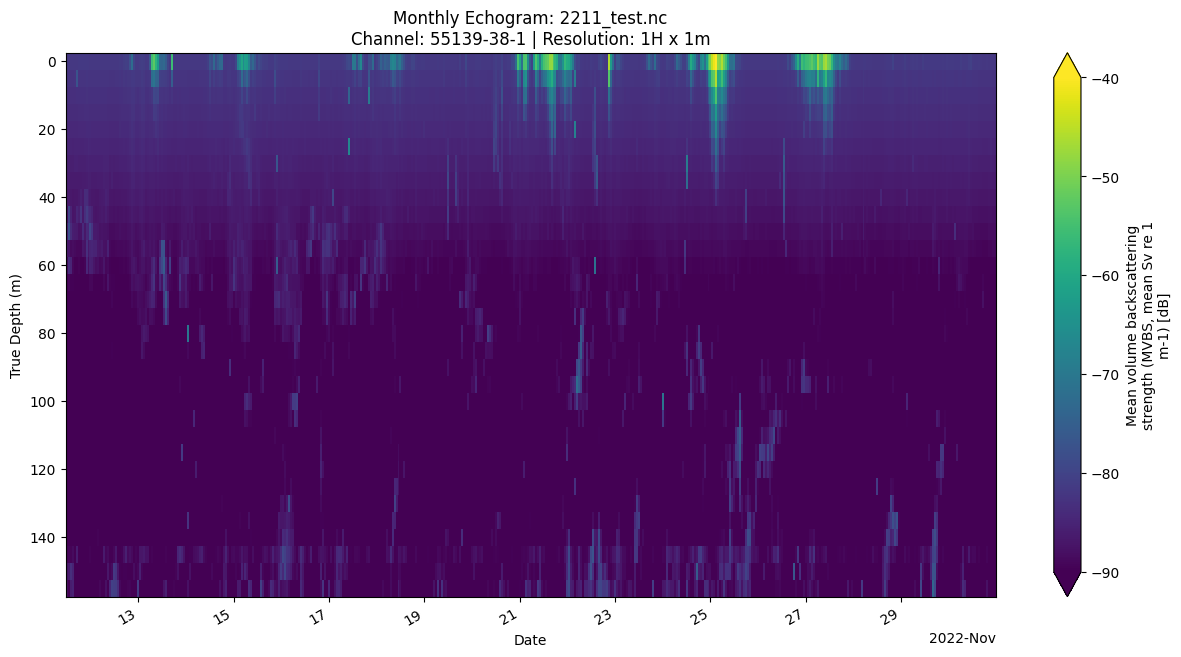


Data Range: 2022-11-11T12:00:00.000000000 to 2022-11-30T23:00:00.000000000
Depth Range: 0.0m to 155.0m


In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import glob
import os
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
input_folder = 'data_products_monthly'  # Where you saved the monthly file
file_pattern = '*.nc'                   # Finds any .nc file in that folder

# ---------------------------

# 1. Find the Monthly File
search_path = os.path.join(input_folder, file_pattern)
file_list = sorted(glob.glob(search_path))

if not file_list:
    print(f"No files found in {input_folder}")
else:
    # If multiple files exist, let user choose, otherwise pick the first
    print("Found files:")
    for idx, f in enumerate(file_list):
        print(f"{idx + 1}: {os.path.basename(f)}")
    
    file_index = int(input("\nSelect file number to plot (default 1): ") or 1) - 1
    target_file = file_list[file_index]

    print(f"\nOpening {os.path.basename(target_file)}...")
    ds = xr.open_dataset(target_file)

    # 2. Select Channel
    available_channels = ds.channel.values
    print("\n--- Available Channels ---")
    for index, channel_name in enumerate(available_channels):
        print(f"{index + 1}: {channel_name}")

    try:
        sel = int(input("Select Channel Number: ")) - 1
        selected_channel_id = available_channels[sel]
    except:
        selected_channel_id = available_channels[0]
        print("Defaulting to first channel.")

    # 3. Prepare Data for Plotting
    ds_plot = ds.sel(channel=selected_channel_id)

    # Ensure we plot against Depth (if available) or calculate it
    if 'depth' in ds_plot.coords:
        y_axis = 'depth'
        y_label = "True Depth (m)"
    elif 'echo_range' in ds_plot.coords:
        # Fallback if depth was not saved
        # Note: You might need to update mooring_depth if this happens
        y_axis = 'echo_range'
        y_label = "Range (m)"
    else:
        print("Error: No depth or range coordinate found.")
        y_axis = None

    if y_axis:
        # 4. Generate the Plot
        plt.figure(figsize=(15, 8)) # Wide figure for a whole month
        
        # The Plot Command
        ds_plot['Sv'].plot(
            x='ping_time',
            y=y_axis,
            cmap='viridis',  # 'viridis' or 'jet' or 'plasma'
            vmin=-90,        # Minimum dB (Quiet)
            vmax=-40         # Maximum dB (Loud) - Tweaked for MVBS
        )

        # Invert Y-axis so Surface (0m) is at the top
        plt.gca().invert_yaxis()

        # Formatting
        plt.title(f"Monthly Echogram: {os.path.basename(target_file)}\nChannel: {selected_channel_id} | Resolution: 1H x 1m")
        plt.ylabel(y_label)
        plt.xlabel("Date")
        
        # Format X-axis dates nicely
        plt.gcf().autofmt_xdate()

        plt.show()

        # Print quick stats
        print(f"\nData Range: {ds_plot.ping_time.min().values} to {ds_plot.ping_time.max().values}")
        print(f"Depth Range: {ds_plot[y_axis].min().values:.1f}m to {ds_plot[y_axis].max().values:.1f}m")

### automating plot

In [ ]:
ds.depth

<xarray.DataArray 'depth' (depth: 159)> Size: 1kB
array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
        12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,  23.,
        24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,  34.,  35.,
        36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,  45.,  46.,  47.,
        48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,  56.,  57.,  58.,  59.,
        60.,  61.,  62.,  63.,  64.,  65.,  66.,  67.,  68.,  69.,  70.,  71.,
        72.,  73.,  74.,  75.,  76.,  77.,  78.,  79.,  80.,  81.,  82.,  83.,
        84.,  85.,  86.,  87.,  88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,
        96.,  97.,  98.,  99., 100., 101., 102., 103., 104., 105., 106., 107.,
       108., 109., 110., 111., 112., 113., 114., 115., 116., 117., 118., 119.,
       120., 121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
       132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142., 143.,
       144., 145., 146., 147., 148., 149., 150., 151., 152., 153., 154., 155.,
       156., 157., 158.])
Coordinates:
  * depth    (depth) float64 1kB 0.0 1.0 2.0 3.0 4.0 ... 155.0 156.0 157.0 158.0
Attributes:
    long_name:  Range distance
    units:      m

: 

In [12]:
import xarray as xr
import matplotlib.pyplot as plt
import glob
import os
import warnings
import ipywidgets as widgets
from IPython.display import display, clear_output

# Suppress warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
input_folder = 'data_products_monthly'  # Where you saved the monthly file
file_pattern = '*.nc'                   # Finds any .nc file

# 1. Find Files
search_path = os.path.join(input_folder, file_pattern)
file_list = sorted(glob.glob(search_path))
file_names = [os.path.basename(f) for f in file_list]

if not file_list:
    print(f"No files found in {input_folder}")
else:
    # --- WIDGET DEFINITIONS ---
    
    # Dropdown for Files
    file_dropdown = widgets.Dropdown(
        options=file_names,
        value=file_names[0],
        description='Month:',
        style={'description_width': 'initial'}
    )

    # Dropdown for Channels (Initially empty, populated dynamically)
    channel_dropdown = widgets.Dropdown(
        options=[],
        description='Channel:',
        disabled=False,
        style={'description_width': 'initial'}
    )

    # Button to trigger plotting
    plot_button = widgets.Button(
        description='Plot Echogram',
        button_style='primary', # 'success', 'info', 'warning', 'danger' or ''
        icon='chart-line'
    )

    # Output area where the plot will appear
    output_plot = widgets.Output()

    # --- LOGIC FUNCTIONS ---

    def get_full_path(filename):
        return os.path.join(input_folder, filename)

    def update_channels(*args):
        """Opens the selected file and updates the channel dropdown options."""
        current_file = get_full_path(file_dropdown.value)
        try:
            with xr.open_dataset(current_file) as ds:
                channels = list(ds.channel.values)
                channel_dropdown.options = channels
                channel_dropdown.value = channels[0] # Default to first channel
        except Exception as e:
            channel_dropdown.options = ['Error reading file']
            print(f"Error: {e}")

    def on_plot_click(b):
        """The main function that runs when you click 'Plot'."""
        with output_plot:
            clear_output(wait=True) # Clear previous plot
            
            target_file = get_full_path(file_dropdown.value)
            selected_channel = channel_dropdown.value
            
            print(f"Plotting {selected_channel} from {os.path.basename(target_file)}...")
            
            try:
                # Open Data
                ds = xr.open_dataset(target_file)
                ds_plot = ds.sel(channel=selected_channel)

                # Determine Y-Axis (Depth vs Range)
                if 'depth' in ds_plot.coords:
                    y_axis = 'depth'
                    y_label = "True Depth (m)"
                elif 'echo_range' in ds_plot.coords:
                    y_axis = 'echo_range'
                    y_label = "Range (m)"
                else:
                    print("Error: No depth or range coordinate found.")
                    return

                # PLOTTING
                plt.figure(figsize=(15, 8))
                
                ds_plot['Sv'].plot(
                    x='ping_time',
                    y=y_axis,
                    cmap='viridis',
                    vmin=-90,
                    vmax=-40  
                )

                plt.gca().invert_yaxis()
                plt.title(f"Monthly Echogram: {os.path.basename(target_file)}\nChannel: {selected_channel} | Resolution: 1H x 1m")
                plt.ylabel(y_label)
                plt.xlabel("Date")
                plt.gcf().autofmt_xdate()
                plt.show()

                # Print Stats
                print(f"Date Range: {ds_plot.ping_time.min().values} to {ds_plot.ping_time.max().values}")
                print(f"Depth Range: {ds_plot[y_axis].min().values:.1f}m to {ds_plot[y_axis].max().values:.1f}m")
                
            except Exception as e:
                print(f"Error plotting: {e}")

    # --- CONNECT WIDGETS ---
    
    # When file changes, run update_channels
    file_dropdown.observe(update_channels, names='value')
    
    # When button clicks, run plotting
    plot_button.on_click(on_plot_click)

    # Initialize channels for the first file in the list
    update_channels()

    # --- DISPLAY ---
    # Create a nice layout
    ui = widgets.VBox([
        widgets.HBox([file_dropdown, channel_dropdown]),
        plot_button,
        output_plot
    ])
    
    display(ui)

### To zoom in to the missing lines in high res

Opening high-res file: 22120100.nc...


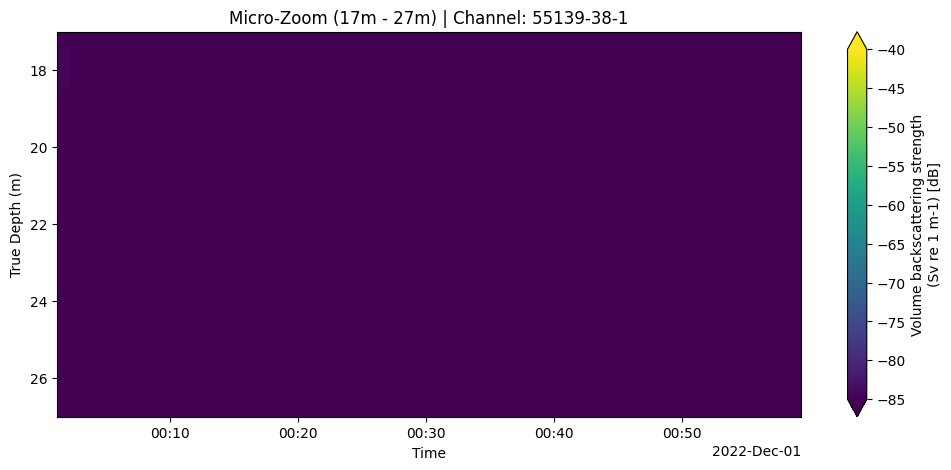


--- RAW DATA CHECK (First Ping around 18m) ---
Raw Depth Coordinates recorded by instrument:
[[126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 123.98]
 [126.   124.99 12

In [6]:
import echopype as ep
import xarray as xr
import matplotlib.pyplot as plt
import glob
import os
import warnings
import numpy as np

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
input_folder = 'data_processed/202212_nc' # Folder with RAW daily/hourly files
file_pattern = '*.nc'                     # Just grabs the first available file

# 1. Find a single file to test
search_path = os.path.join(input_folder, file_pattern)
files = sorted(glob.glob(search_path))

if not files:
    print("No files found!")
else:
    test_file = files[0] # Grab the very first file
    print(f"Opening high-res file: {os.path.basename(test_file)}...")
    
    # 2. Open and Calibrate
    ed = ep.open_converted(test_file)
    ds_Sv = ep.calibrate.compute_Sv(ed, env_params={'temperature': 4, 'salinity': 35, 'pressure': 160})
    
    # 3. Add Depth
    if 'echo_range' in ds_Sv.coords:
        range_var = ds_Sv.coords['echo_range']
    else:
        range_var = ds_Sv.data_vars['echo_range']
        
    ds_Sv = ds_Sv.assign_coords(depth = 159 - range_var)
    
    # Select Channel (Defaulting to the first one, usually 38kHz)
    target_channel = ds_Sv.channel.values[0] 
    da_plot = ds_Sv['Sv'].sel(channel=target_channel)

    # --- 4. PLOT THE MICRO-ZOOM ---
    plt.figure(figsize=(12, 5))
    
    # We plot the data normally...
    da_plot.plot(
        x='ping_time',
        y='depth',
        cmap='viridis',
        vmin=-85,
        vmax=-40
    )
    
    # ...But we forcefully crop the Y-axis to only show 17m to 27m
    # We put 27 first and 17 second to invert the axis (Surface at the top)
    plt.ylim(27, 17) 
    
    plt.title(f"Micro-Zoom (17m - 27m) | Channel: {target_channel}")
    plt.ylabel("True Depth (m)")
    plt.xlabel("Time")
    plt.show()

    # --- 5. THE ULTIMATE PROOF (PRINT RAW DATA) ---
    print("\n--- RAW DATA CHECK (First Ping around 18m) ---")
    
    # Slice exactly between 17.5m and 18.5m
    depth_slice = da_plot.where((da_plot.depth >= 123) & (da_plot.depth <= 126), drop=True)
    
    print(f"Raw Depth Coordinates recorded by instrument:")
    # Print the depth values rounded to 2 decimal places
    print(np.round(depth_slice.depth.values, 2))
    
    print(f"\nRaw Sv Values for the very first ping at these depths:")
    # Print the actual dB values (will say 'nan' if missing)
    print(depth_slice.isel(ping_time=0).values)

In [ ]:
!pip install ipywidgets                                                         

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 914.9/914.9 kB 4.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ----------------------- ---------------- 1.3/2.2 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 6.2 MB/s  0:00:00

   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]



## Check for inverted

In [2]:
import echopype as ep
import xarray as xr
import glob
import os
import warnings
import numpy as np

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# --- USER CONFIGURATION ---
input_folder = 'data_processed/202304_nc'   # Folder with your daily/hourly NC files
file_pattern = input("Enter the file pattern (e.g., '2304*.nc' for all April): ")

output_folder = 'data_products_monthly'
output_filename = 'AZFP_Station27_April_test_w/o_surface_MVBS.nc' # Name of the final file

# Mooring Definitions
mooring_depth = 159      # Sensor is at what m
bad_line_min = 97        # Interference top
bad_line_max = 102       # Interference bottom
surface_cutoff = 0       # Keep data only DEEPER than 0m (Remove surface)

# Binning Resolution
res_time = "1H"          # 1 Hour resolution
res_depth = "1m"         # 1 Meter resolution

# ---------------------------

# 1. Setup Output Directory
os.makedirs(output_folder, exist_ok=True) # if no output folder, create it

# 2. Find Files
search_path = os.path.join(input_folder, file_pattern)
file_list = sorted(glob.glob(search_path))

print(f"Found {len(file_list)} files. Starting processing...")
print(f"Target: Single file with {res_time} x {res_depth}m resolution.")
print(f"Applying Masks: Surface (<{surface_cutoff}m) and Lines ({bad_line_min}-{bad_line_max}m)")

mvbs_datasets = []

# 3. Main Processing Loop
for i, file in enumerate(file_list):
    try:
        print(f"[{i+1}/{len(file_list)}] Processing {os.path.basename(file)}...", end='\r')
        
        # A. Open & Calibrate
        ed = ep.open_converted(file)
        env_params = {
            'temperature': 4, 
            'salinity': 35, 
            'pressure': mooring_depth * 1.01
        }
        ds_Sv = ep.calibrate.compute_Sv(ed, env_params=env_params)

        # B. Robust Echo Range Extraction
        # (Ensures we can calculate depth even if metadata varies)
        if 'echo_range' in ds_Sv.coords:
            range_var = ds_Sv.coords['echo_range']
        elif 'echo_range' in ds_Sv.data_vars:
            range_var = ds_Sv.data_vars['echo_range']
            ds_Sv = ds_Sv.assign_coords(echo_range=range_var)
        else:
            print(f"Skipping {os.path.basename(file)} (Missing echo_range)")
            continue

        # C. Calculate True Depth
        # Depth = Sensor Depth (168) - Range
        true_depth = mooring_depth - ds_Sv['echo_range']
        ds_Sv = ds_Sv.assign_coords(depth=true_depth)

        # --- D. APPLY MASKS (The "Filters") ---
        

        # Mask 2: Interference Lines (97-102m)
        # We keep data that is NOT in the bad zone
        mask_good_lines = (ds_Sv['depth'] < bad_line_min) | (ds_Sv['depth'] > bad_line_max)
        ds_Sv['Sv'] = ds_Sv['Sv'].where(mask_good_lines)

        # --- E. BINNING (Compute MVBS) ---
        # This condenses the data:
        # Time: Averages all pings in 1 Hour
        # Depth: Averages all samples in 1 Meter (Range)
        # Note: Binning by Range (1m) is equivalent to binning by Depth (1m)
        ds_mvbs = ep.commongrid.compute_MVBS(
            ds_Sv,
            range_var='depth',  # Use the calculated depth for binning
            range_bin=res_depth, 
            ping_time_bin=res_time
        )

        mvbs_datasets.append(ds_mvbs)

    except Exception as e:
        print(f"\nError on {os.path.basename(file)}: {e}")
        continue

# 4. Concatenate & Save
print("\n\nMerging daily data into one file...")

if mvbs_datasets:
    # Combine all the small binned files into one big dataset
    ds_monthly = xr.concat(mvbs_datasets, dim='ping_time')
    
    # Re-calculate Depth for the final file
    # (Because MVBS bins by range, we add the depth coordinate back for easy plotting later)
    if 'echo_range' in ds_monthly.coords:
        final_depth = mooring_depth - ds_monthly['echo_range']
        ds_monthly = ds_monthly.assign_coords(depth=final_depth)
    
    # Save
    save_path = os.path.join(output_folder, output_filename)
    ds_monthly.to_netcdf(save_path)
    
    print(f"SUCCESS! Monthly file saved to:")
    print(f" -> {save_path}")
else:
    print("No data processed.")

Found 720 files. Starting processing...
Target: Single file with 1H x 1mm resolution.
Applying Masks: Surface (<0m) and Lines (97-102m)
[720/720] Processing 23043023.nc...

Merging daily data into one file...


PermissionError: [Errno 13] Permission denied: 'd:\\Work\\NekTone-Processing-AZFP\\data_products_monthly\\AZFP_Station27_April_test_w\\o_surface_MVBS.nc'

In [4]:
output_filename = 'AZFP_Station27_April_test_wo_surface_MVBS.nc'
save_path = os.path.join(output_folder, output_filename)
ds_monthly.to_netcdf(save_path)
    
print(f"SUCCESS! Monthly file saved to:")
print(f" -> {save_path}")

SUCCESS! Monthly file saved to:
 -> data_products_monthly\AZFP_Station27_April_test_wo_surface_MVBS.nc


## test again with surface

In [10]:
import echopype as ep
import xarray as xr
import glob
import os
import warnings
import numpy as np

# Suppress warnings
warnings.filterwarnings('ignore')

# --- USER CONFIGURATION ---
input_folder = 'data_processed/202304_nc'
file_pattern = input("Enter the file pattern (e.g., '2304*.nc' for all April): ")

output_folder = 'data_products_monthly'
output_filename = 'AZFP_Station27_April_Surface_Test.nc' 

# Mooring Definitions
mooring_depth = 159      # Sensor Depth
bad_line_min = 97        # Interference top
bad_line_max = 102       # Interference bottom

# Binning Resolution
res_time = "1H"          # 1 Hour
res_depth = "1m"         # 1 Meter

# ---------------------------

os.makedirs(output_folder, exist_ok=True)
search_path = os.path.join(input_folder, file_pattern)
file_list = sorted(glob.glob(search_path))

print(f"Found {len(file_list)} files. Processing...")
print("Binning by RANGE first (Robust Method), then calculating Depth.")

mvbs_datasets = []

for i, file in enumerate(file_list):
    try:
        print(f"[{i+1}/{len(file_list)}] Processing {os.path.basename(file)}...", end='\r')
        
        # 1. Open & Calibrate
        ed = ep.open_converted(file)
        env_params = {
            'temperature': 4, 
            'salinity': 35, 
            'pressure': mooring_depth * 1.01
        }
        ds_Sv = ep.calibrate.compute_Sv(ed, env_params=env_params)

        # 2. Robust Echo Range
        if 'echo_range' in ds_Sv.coords:
            range_var = ds_Sv.coords['echo_range']
        elif 'echo_range' in ds_Sv.data_vars:
            range_var = ds_Sv.data_vars['echo_range']
            ds_Sv = ds_Sv.assign_coords(echo_range=range_var)
        else:
            continue

        # 3. Calculate Depth (Just for Masking Lines)
        true_depth = mooring_depth - ds_Sv['echo_range']
        ds_Sv = ds_Sv.assign_coords(depth=true_depth)

        # --- APPLY MASKS ---
        # Note: We are NOT masking the surface (depth < 0) because you want to see it.
        
        # Mask: Interference Lines (97-102m)
        mask_good_lines = (ds_Sv['depth'] < bad_line_min) | (ds_Sv['depth'] > bad_line_max)
        ds_Sv['Sv'] = ds_Sv['Sv'].where(mask_good_lines)

        # --- BINNING (THE FIX) ---
        # We bin by 'echo_range' (0 to Max) instead of 'depth'.
        # This ensures we capture the "Surface" data which is at the far end of the range.
        ds_mvbs = ep.commongrid.compute_MVBS(
            ds_Sv,
            range_var='echo_range', # Binning the native range
            range_bin=res_depth, 
            ping_time_bin=res_time
        )

        mvbs_datasets.append(ds_mvbs)

    except Exception as e:
        print(f"\nError on {os.path.basename(file)}: {e}")
        continue

# --- CONCATENATE & SAVE ---
print("\n\nMerging and Finalizing...")

if mvbs_datasets:
    ds_monthly = xr.concat(mvbs_datasets, dim='ping_time')
    
    # --- RE-CALCULATE DEPTH FOR PLOTTING ---
    # Now that we have binned ranges (e.g. 0, 1, ... 160m), 
    # we convert them to True Depth (e.g. 159, 158, ... -1m)
    if 'echo_range' in ds_monthly.coords:
        final_depth = mooring_depth - ds_monthly['echo_range']
        ds_monthly = ds_monthly.assign_coords(depth=final_depth)
    
    # Save
    save_path = os.path.join(output_folder, output_filename)
    ds_monthly.to_netcdf(save_path)
    
    print(f"SUCCESS! Saved to: {save_path}")
    print("You can now plot this file. The 'depth' coordinate will include negative values (Air).")
else:
    print("No data processed.")

Found 720 files. Processing...
Binning by RANGE first (Robust Method), then calculating Depth.
[720/720] Processing 23043023.nc...

Merging and Finalizing...
SUCCESS! Saved to: data_products_monthly\AZFP_Station27_April_Surface_Test.nc
You can now plot this file. The 'depth' coordinate will include negative values (Air).
